### Stochastic interpolant demo: unit Gaussian → Gaussian mixture 

We learn a generative map from a simple **base** distribution to a more complex
**target**:

- **Base** `p_0`: a single unit Gaussian, `N(0, I)` (unit variance, zero covariance).
- **Target** `p_1`: a 16D Gaussian mixture model with randomized mean and covariances.

The `EESI` model trains a drift field `b(t, x)` and (optionally) score field `s(t, x)` along
the stochastic interpolant

$$x_t = \alpha(t)\,x_0 + \beta(t)\,x_1 + \gamma(t)\,z,\qquad z\sim N(0, I),$$

then estimates the entropy difference using a variety of strategies:
- integrate the learned probability-flow ODE (or reverse-time SDE) from
`t=0` (base) to `t=1` (target), acculumating entropy as `b * s` along the paths. 
- directly sample the interpolant, taking the average of `b * s`
- directly sample the interpolant, taking the average of `div(b)` independent of the score

This notebook covers **setup & instantiation**,
the **training loop**, **sampling**, and **contour plotting**.

In [17]:
# --- imports & environment ---
import sys
import pathlib

import torch
import numpy as np
import matplotlib.pyplot as plt
import scipy.special
from torch.distributions import MultivariateNormal

# Make the `eesi` package importable whether the notebook is launched from the
# repo root or from this experiments/ folder (no install required).
_cwd = pathlib.Path.cwd()
for _root in (_cwd, _cwd.parent, _cwd.parent.parent):
    if (_root / "eesi" / "__init__.py").exists():
        sys.path.insert(0, str(_root))
        break
from eesi import EESI, TimeMLP, GaussianMixture, toy_transport_cost
# `train` is deliberately not re-exported at the package level -- training
# modules are imported directly. See eesi/systems/__init__.py.
from eesi.systems.toy.train import train

%matplotlib inline
torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### 1. Base and target distributions

The base is standard normal, `N(0, I)`. The target is a two-component Gaussian
mixture built from `eesi.datasets.GaussianMixture`, whose weights, means and
full (correlated) covariances are drawn once from a fixed `seed` and then held
constant.

In [18]:
d = 40
# --- base: single 2D Gaussian, unit variance, zero covariance ---
base = MultivariateNormal(torch.zeros(d, device=device), torch.eye(d, device=device))

# --- target: 3-component Gaussian mixture from eesi.datasets.GaussianMixture ---
# The mixture draws its weights, means and full covariances once (fixed `seed`)
# and holds them constant; `sigma` sets how far apart the component means are.
target = GaussianMixture(dim=d,n_mixes=16,loc_scaling=2,log_var_scaling=-3,seed=10,device=device)

# Sanity check: draw and scatter samples from each distribution.
x0_vis = base.sample((2000,)).cpu()
x1_vis = target.sample((2000,)).cpu()


### 2. Model & sampler setup

`EESI` wraps two `TimeMLP` fields — the drift `net_b` and the score `net_s`.

- `path="trig2"` uses the ramped interpolant `x_t = cos^2(\u03c0t/2) x_0 + sin^2(\u03c0t/2) x_1`,
  whose velocity vanishes at both endpoints.
- `gamma="sqrt"` adds the latent-noise schedule `\u03b3(t) = sqrt(t(1-t))`, so the
  score is trained with the cheap antithetic denoising objective (no divergence
  estimate). Try `gamma="sin2"` / `gamma="none"`, or `path="linear"`/`"trig"`.


In [21]:
net_b = TimeMLP(d=d, hidden=256, n_layers=5, activation="gelu")
net_s = TimeMLP(d=d, hidden=384, n_layers=5, activation="gelu")

model = EESI(
    net_b, net_s,
    d=d,
    path="linear",
    gamma="sqrt",
    gamma_scale=0.2,
    learn_score=True
).to(device)

#print(model)
print(sum(p.numel() for p in model.net_b.parameters()))
print(sum(p.numel() for p in model.net_s.parameters()))


481064
1065640


### 3. Training loop

`eesi.systems.toy.train.train` runs the loop: each iteration draws a fresh batch from
the target `x_1` and from the base `x_0`, couples them by **minibatch optimal transport**
(`eesi.systems.toy.ot`, squared-Euclidean cost, no symmetry group -- the base is
rotationally invariant but the target is not), forms the interpolant internally, and
returns the drift/score losses. Here we minimise the score loss alone (`learn_vel=False`).

Set `batch_ot=False` for the ablation: the independent coupling this notebook used
before, i.e. pairing the two batches in the order they were drawn.

In [ ]:
# The training loop used to live here. It is now
# `eesi.systems.toy.train.train`, imported above -- same loop, plus the OT coupling
# and the fixed-dataset target mode from 2D_NonGaussian.ipynb.

In [31]:
model, hist = train(target, steps=100_000, batch=1000, lr=1e-4, batch_ot=True,
                    learn_vel=False, device=device, model=model, log_every=1000)
tot_hist_b, tot_hist_s = np.asarray(hist).T

#model, hist = train(target, steps=100_000, batch=1000, lr=1e-4, batch_ot=True,
#                    learn_vel=False, device=device, model=model, log_every=1000)
#tot_hist_b = np.concatenate([tot_hist_b, np.asarray(hist)[:, 0]])
#tot_hist_s = np.concatenate([tot_hist_s, np.asarray(hist)[:, 1]])

iter    0  loss_b=-36.343  loss_s=-473.340
iter 1000  loss_b=-36.918  loss_s=-466.304
iter 2000  loss_b=-36.403  loss_s=-490.395
iter 3000  loss_b=-37.594  loss_s=-507.589
iter 4000  loss_b=-36.263  loss_s=-434.004
iter 5000  loss_b=-36.348  loss_s=-530.375
iter 6000  loss_b=-36.423  loss_s=-484.824
iter 7000  loss_b=-36.033  loss_s=-494.429
iter 8000  loss_b=-36.937  loss_s=-542.047
iter 9000  loss_b=-36.206  loss_s=-476.171
iter 10000  loss_b=-36.827  loss_s=-541.937
iter 11000  loss_b=-36.884  loss_s=-488.341
iter 12000  loss_b=-36.738  loss_s=-508.590
iter 13000  loss_b=-36.878  loss_s=-457.661
iter 14000  loss_b=-36.873  loss_s=-586.742
iter 15000  loss_b=-35.764  loss_s=-421.020
iter 16000  loss_b=-36.867  loss_s=-525.169
iter 17000  loss_b=-37.038  loss_s=-491.419
iter 18000  loss_b=-36.915  loss_s=-482.876
iter 19000  loss_b=-36.183  loss_s=-479.477
iter 20000  loss_b=-36.962  loss_s=-502.160
iter 21000  loss_b=-37.555  loss_s=-445.475
iter 22000  loss_b=-35.751  loss_s=-560.93

KeyboardInterrupt: 

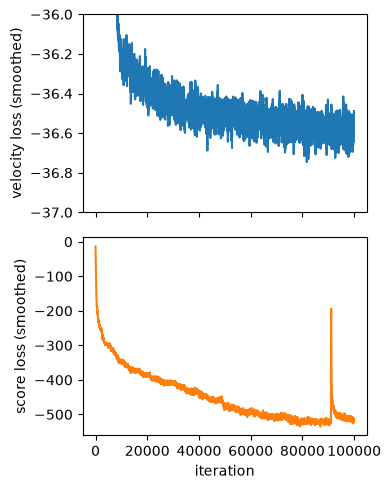

In [32]:
# Training curves (smoothed).
def smooth(v, k=100):
    v = np.asarray(v)
    if len(v) < k:
        return v
    return np.convolve(v, np.ones(k) / k, mode="valid")

fig, ax = plt.subplots(2,1,sharex=True,figsize=(4,5))
ax[0].plot(smooth(tot_hist_b),'-C0')
ax[0].set_ylabel("velocity loss (smoothed)")
ax[1].plot(smooth(tot_hist_s),'-C1')
ax[1].set_xlabel("iteration") 
ax[1].set_ylabel("score loss (smoothed)")
ax[0].set_ylim(-37,-36)
plt.tight_layout()
plt.show()

### 4. Sampling

Map base samples to the target with the model's built-in samplers:

- `model.sample_ode` integrates the probability-flow **ODE** `dx/dt = b(t, x)`
  with Heun's method (drift only).
- `model.sample_sde` integrates the reverse-time **SDE** with Euler–Maruyama,
  using both the drift `b` and the learned score `s` (diffusion `eps`).

In [25]:
# Draw base samples and push them through the model's built-in samplers.
x0 = base.sample((20000,))
x1 = target.sample((20000,))
gen_ode = model.sample(x0, n_steps=100)            # probability-flow ODE (drift only)
gen_sde = model.sample(x0, n_steps=100, eps=0.05)     # reverse-time SDE (drift + score)

# How well do generated samples match the target? (mean log-density)
ref = target.log_prob(x1).mean()
base_ref = base.log_prob(x0).mean()
print(f"mean target log-prob \u2014 true target : {ref:+.3f}")
print(f"mean target log-prob \u2014 ODE sampler : {target.log_prob(gen_ode).mean():+.3f}")
print(f"percent error in log-prod, ODE sampler : {100*(target.log_prob(gen_ode).mean()-ref)/ref:+.3f}%")
print(f"mean target log-prob \u2014 SDE sampler : {target.log_prob(gen_sde).mean():+.3f}")
print(f"percent error in log-prod, SDE sampler : {100*(target.log_prob(gen_sde).mean()-ref)/ref:+.3f}%")
print(f"mean base   log-prob \u2014 true base   : {base_ref:+.3f}")
print(f"estimated entropy change : {-ref + base_ref:+.3f}")
delta_pred = -ref + base_ref
delta_pred = delta_pred.cpu().numpy()


mean target log-prob — true target : +61.476
mean target log-prob — ODE sampler : +39.235
percent error in log-prod, ODE sampler : -36.179%
mean target log-prob — SDE sampler : +29.580
percent error in log-prod, SDE sampler : -51.884%
mean base   log-prob — true base   : -56.755
estimated entropy change : -118.232


### 5. Entropy along the paths

The trajectory-returning `*_entropy_traj` samplers augment every path with the
running integral

$$\Delta\text{S}(t) = -\int_0^t b(x_{t'}, t')\cdot s(x_{t'}, t')\,dt',$$

an estimate of how the (differential) entropy of the flowing density changes as
samples move from base to target. With `sample_ode_entropy_traj` we get the full
`ΔS(t)` curve for every sample at once, so we can plot many paths together
and read off the ensemble-mean entropy change.

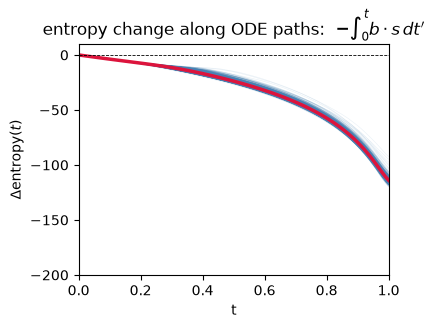

-118.23154
-113.932045
0.09765924
-0.036365017


In [26]:
# Trace the running entropy change along many ODE paths.
torch.seed()
batch = 1000

means = []
for k in range(20):
    x0 = base.sample((batch,))
    traj, ent_traj, ts = model.sample(x0, n_steps=100, entropy='div', return_traj=True)
    means.append(ent_traj[-1, :].mean().cpu().numpy())

ts_c = ts.cpu().numpy()
ent_c = ent_traj.cpu().numpy()[:, :1000]         # first 1000 paths [n_steps+1, B]

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(ts_c, ent_c, c="steelblue", lw=0.4, alpha=0.12)                  # individual paths
ax.plot(ts_c, ent_c.mean(axis=1), c="crimson", lw=2.5, label="ensemble mean")
ax.axhline(0.0, c="k", lw=0.6, ls="--")
ax.set_xlabel("t"); ax.set_ylabel(r"$\Delta$entropy$(t)$")
ax.set_title(r"entropy change along ODE paths:  $-\int_0^t b\cdot s\,dt'$")
ax.set_ylim(-200,10)
ax.set_xlim(0,1)
plt.show()

print(delta_pred)
print(np.mean(means))
print(np.std(means))
print((np.mean(means)-delta_pred)/delta_pred)


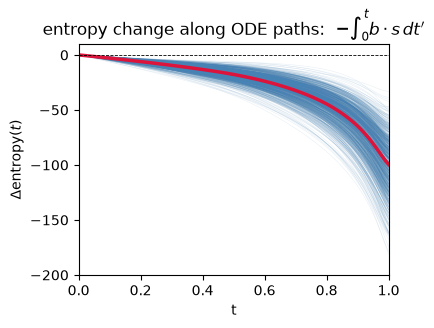

-118.23154
-98.97856
0.9308596
-0.16284129


In [27]:
# Trace the running entropy change along many ODE paths.
torch.seed()
batch = 1000

means = []
for k in range(20):
    x0 = base.sample((batch,))
    traj, ent_traj, ts = model.sample(x0, n_steps=100, entropy='dot', return_traj=True)
    means.append(ent_traj[-1, :].mean().cpu().numpy())

ts_c = ts.cpu().numpy()
ent_c = ent_traj.cpu().numpy()[:, :1000]         # first 1000 paths [n_steps+1, B]

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(ts_c, ent_c, c="steelblue", lw=0.4, alpha=0.12)                  # individual paths
ax.plot(ts_c, ent_c.mean(axis=1), c="crimson", lw=2.5, label="ensemble mean")
ax.axhline(0.0, c="k", lw=0.6, ls="--")
ax.set_xlabel("t"); ax.set_ylabel(r"$\Delta$entropy$(t)$")
ax.set_title(r"entropy change along ODE paths:  $-\int_0^t b\cdot s\,dt'$")
ax.set_ylim(-200,10)
ax.set_xlim(0,1)
plt.show()

print(delta_pred)
print(np.mean(means))
print(np.std(means))
print((np.mean(means)-delta_pred)/delta_pred)


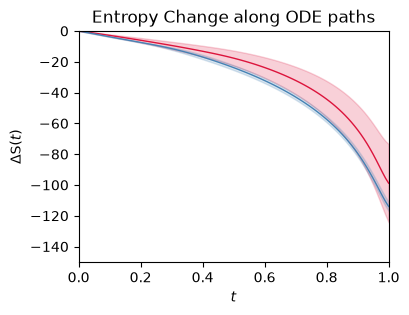

In [28]:
# Trace the running entropy change along many SDE paths.
torch.seed()
batch = 10000

x0 = base.sample((batch,))
traj, ent_traj, ts = model.sample(x0, n_steps=100, entropy='dot', return_traj=True)
ts_c = ts.cpu().numpy()
ent_c = ent_traj.cpu().numpy()
dot_mean = ent_c.mean(axis=1)
dot_std = ent_c.std(axis=1)

traj, ent_traj, ts = model.sample(x0, n_steps=100, entropy='div', return_traj=True)
ent_c = ent_traj.cpu().numpy()
div_mean = ent_c.mean(axis=1)
div_std = ent_c.std(axis=1)

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(ts_c, dot_mean, c="crimson", lw=1, label="Dot Product")
ax.fill_between(ts_c, dot_mean - dot_std, dot_mean + dot_std, color='crimson', alpha=0.2)
ax.plot(ts_c, div_mean, c="steelblue", lw=1, label="Divergence")
ax.fill_between(ts_c, div_mean - div_std, div_mean + div_std, color='steelblue', alpha=0.2)

ax.set_xlabel(r"$t$"); ax.set_ylabel(r"$\Delta$S$(t)$")
ax.set_title(r"Entropy Change along ODE paths")
ax.set_ylim(-150,0)
ax.set_xlim(0,1)
plt.show()


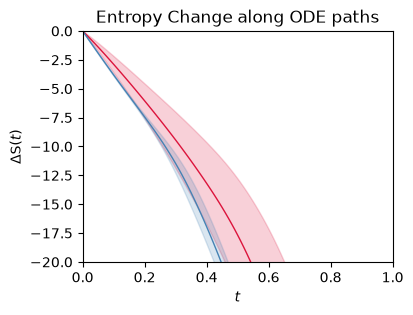

In [29]:
fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(ts_c, dot_mean, c="crimson", lw=1, label="Dot Product")
ax.fill_between(ts_c, dot_mean - dot_std, dot_mean + dot_std, color='crimson', alpha=0.2)
ax.plot(ts_c, div_mean, c="steelblue", lw=1, label="Divergence")
ax.fill_between(ts_c, div_mean - div_std, div_mean + div_std, color='steelblue', alpha=0.2)

ax.set_xlabel(r"$t$"); ax.set_ylabel(r"$\Delta$S$(t)$")
ax.set_title(r"Entropy Change along ODE paths")
ax.set_ylim(-20,0)
ax.set_xlim(0,1)
plt.show()

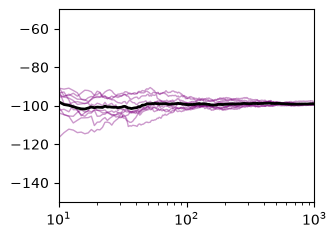

-98.9756
0.19138856
-0.16286632


In [30]:
# Examine convergence based on number of trajectories simulated
vals = []
torch.seed()
batch = 10000

plt.figure(figsize=(3.3,2.5))

mom = []
for k in range(10):
    x0 = base.sample((batch,))
    x,ent = model.sample(x0, n_steps=100, entropy='dot')
    ent_cpu = ent.cpu().numpy()
    vals.append(np.mean(ent_cpu))
    #print(np.mean(ent_cpu))
    mean = np.cumsum(ent_cpu)/np.arange(1,batch+1)
    mom.append(mean)
    plt.plot(np.arange(1,batch+1),mean,'-',color='purple',alpha=0.4,lw=1)
mom = np.mean(mom,axis=0)
plt.plot(np.arange(1,batch+1),mom,'-',color='k',lw=2)
#plt.yscale('log')
plt.xscale('log')
plt.xlim(10,1000)
plt.ylim(-150,-50)
plt.show()
print(np.mean(vals))
print(np.std(vals))
print((np.mean(vals)-delta_pred)/delta_pred)


### 6. Generation-Free Entropy Estimate

In [48]:
torch.manual_seed(1)
batch = 1000
x1 = target.sample((batch,))

means = []
for n in range(1000):
    x0 = base.sample((batch,))
    ent = model.entropy_estimate(x1, x0, method='dot')   # b*s formulation
    means.append(ent.mean().cpu().numpy())
print(np.mean(means))
print(np.std(means))
print((np.mean(means)-delta_pred)/delta_pred)


-97.95693
3.0533319
-0.17140467


Somewhat less accurate than I'd like. Not sure why exactly. Perhaps there is some reparameterization or conditioning that can be done to improve this.

In [51]:
torch.manual_seed(1)
batch = 1000
x1 = target.sample((batch,))

means = []
for n in range(1000):
    x0 = base.sample((batch,))
    ent = model.entropy_estimate(x1, x0, "div")   # div(b) formulation
    means.append(ent.mean().detach().cpu().numpy())
print(delta_pred)
print(np.mean(means))
print(np.std(means))
print((np.mean(means)-delta_pred)/delta_pred)


-118.220474
-117.7232
3.1893318
-0.004206347
